***Part 1: Data Preparation and Engineering***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("/Users/kaylado/littlesteps-visit-analysis/data/visits.csv")

df.head()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
0,6a4a715f-94c5-4b5d-8f51-51f07f298fb6,P59581,N1565,2025-09-02 00:08:24,2025-09-02 00:55:24,Wound Care,East,The nurse changed the wound dressing. The pati...
1,27bfc4de-9dd2-4b6b-b05f-f9560a3fd00f,P66547,N5698,"August 24, 2025 10:42PM","August 25, 2025 12:12AM",General Check-up,East,The nurse reviewed the oxygen level. The patie...
2,9c2d0018-8f20-4789-a383-906d49042fbc,P47919,N3012,2025-09-02 11:07:33,2025/09/02 11:56,Physical Therapy,East,Review is required. The nurse assisted the mob...
3,bbedc08d-0ada-4c8f-bac4-3008ac279a01,P18359,N8991,2025-09-15 21:24:42,2025-09-15 22:12:42,General Check-up,North,Follow-up is required. The nurse reviewed the ...
4,155c3765-22d5-41cc-95f5-a94ef19748ae,P45602,N7948,2025-08-31 07:19:11,2025-08-31 07:47:11,Pyhcisal Therapy,North,ASAP is required. The nurse observed the patie...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   visit_id          1000 non-null   object
 1   patient_id        1000 non-null   object
 2   nurse_id          1000 non-null   object
 3   visit_start_time  1000 non-null   object
 4   visit_end_time    900 non-null    object
 5   service_type      1000 non-null   object
 6   visit_location    1000 non-null   object
 7   nurse_notes       900 non-null    object
dtypes: object(8)
memory usage: 62.6+ KB


In [3]:
df.describe()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
count,1000,1000,1000,1000,900,1000,1000,900
unique,970,430,100,1000,900,8,8,678
top,25e18a0c-9cf3-427c-bedf-0a27e8060396,P29486,N2273,2025-09-02 00:08:24,2025-09-02 00:55:24,Medication Administration,North,The nurse provided the IV line. The patient is...
freq,2,8,19,1,1,243,244,6


In [4]:
df.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
dtype: int64

### Handling Duplicate `visit_id` Records

Initial exploration identified **30 duplicated `visit_id` values** in the dataset.  
Upon inspection, these rows were **not exact duplicates** — they contained different values for fields such as:

- `patient_id`
- `visit_start_time`
- `visit_end_time`
- `nurse_notes`

This suggests that the duplicates may represent **multiple records related to the same visit**, potentially caused by:
- system updates,
- partial data entries,
- or data ingestion inconsistencies.

Instead of removing these records and risking the loss of potentially valuable operational information, all rows were preserved.

To ensure that each record can still be uniquely identified, two additional fields were created:

1. **`visit_sequence`**  
   A sequential counter generated within each `visit_id` group to differentiate records belonging to the same visit.

2. **`visit_record_id`**  
   A new unique identifier constructed as: visit_record_id = visit_id + "_" + visit_sequence


This approach ensures:
- every row has a **unique identifier**,
- the **original visit relationship is preserved**, and
- **no data is lost during preprocessing**.

Maintaining all records while introducing a unique key allows the dataset to remain suitable for further analysis while preserving data integrity.

In [5]:
df["visit_id"].duplicated().sum()

np.int64(30)

There are 30 duplicates in the Visit_id 

In [6]:
df_clean = df.copy()
print(df_clean.shape)

(1000, 8)


In [7]:
duplicate_rows = df_clean[df_clean.duplicated(subset="visit_id", keep=False)].sort_values("visit_id")
duplicate_rows.head(20)

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
627,0c18e2d7-62ba-4ffa-8795-892590a573fe,P28706,N2273,2025-08-20 21:57:21,2025-08-20 23:19:21,General Check-up,North,The nurse reviewed the oxygen level. The patie...
583,0c18e2d7-62ba-4ffa-8795-892590a573fe,P65742,N8955,2025-08-26 12:46:19,2025/08/26 14:01,Medicatn Adminstratino,East,The nurse changed the bandage. The patient is ...
50,179ca7be-e056-4bcd-a7ed-341b5ae14414,P27585,N8721,2025-09-03 08:10:36,NaN,Medication Administration,West,The nurse administered the IV line. The patien...
246,179ca7be-e056-4bcd-a7ed-341b5ae14414,P47490,N3028,2025-08-29 11:20:05,2025-08-29 12:20:05,Medication Administration,East,Follow-up is required. ##--## The nurse admini...
707,1de288da-1cc1-414e-8951-ac251b2e9619,P21550,N6256,09/03/2025 04:55,2025-09-03 05:19:29,General Check-up,South,The nurse observed the temperature. ~@#` The p...
302,1de288da-1cc1-414e-8951-ac251b2e9619,P75705,N9428,2025/09/05 17:10,NaN,Medication Administration,East,The nurse administered the medication. The pat...
561,25e18a0c-9cf3-427c-bedf-0a27e8060396,P51922,N5590,2025-09-10 21:14:53,2025-09-10 21:30:53,Physical Therapy,South,Urgent is required. The nurse assisted the ran...
160,25e18a0c-9cf3-427c-bedf-0a27e8060396,P52548,N4192,2025-09-09 20:57:15,2025-09-09 22:01:15,Wound Care,East,NaN
858,293a0b44-9414-46c6-883e-b2d6ac134c7c,P18410,N3943,09/12/2025 22:04,2025/09/12 23:12,Wound Care,North,The nurse dressed the incision site. The patie...
766,293a0b44-9414-46c6-883e-b2d6ac134c7c,P49432,N1451,2025-09-13 05:02:54,2025/09/13 06:54,Wound Cae,West,The nurse applied the bandage. N/A The patient...


In [8]:
duplicate_counts = df_clean["visit_id"].value_counts()
duplicate_counts[duplicate_counts > 1].head(10)

visit_id
25e18a0c-9cf3-427c-bedf-0a27e8060396    2
ccc6d183-3881-483c-b970-1be4f8d2debe    2
dcb5cd04-4b55-4e2e-bbf2-28acd20a1d4a    2
e2782059-dc8c-4702-90cd-5ee8a336a523    2
293a0b44-9414-46c6-883e-b2d6ac134c7c    2
31e6d04c-02cc-4adf-bd9b-94d47c0077bc    2
de17b966-fbde-4da5-b36a-c171809f614b    2
fe5239d8-3fbd-499b-ba02-c7b9caddc9ae    2
5f7a7c8d-4cdd-477f-ba70-10443522bbef    2
1de288da-1cc1-414e-8951-ac251b2e9619    2
Name: count, dtype: int64

In [9]:
df_clean["visit_sequence"] = df_clean.groupby("visit_id").cumcount() + 1

In [10]:
df_clean["visit_record_id"] = (
    df_clean["visit_id"] + "_" + df_clean["visit_sequence"].astype(str)
)

In [11]:
df_clean["visit_record_id"].duplicated().sum()

np.int64(0)

### Standardizing Text-Based Columns

To ensure consistency across all categorical and text fields, whitespace and formatting inconsistencies were removed from string columns.

All columns with `object` datatype were processed by:
- converting values to string format
- trimming leading and trailing whitespace

This helps prevent issues such as:
- duplicated categories caused by extra spaces
- inconsistent text values affecting grouping or aggregation operations.

After this step, placeholder string values such as `"nan"`, `"None"`, and empty strings were converted into proper `NaN` values using `numpy.nan`.  
This ensures missing values are handled consistently during later analysis.

In [12]:
#Standardize column text formatting
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [13]:
df_clean = df_clean.replace(["nan", "None", ""], np.nan)

In [14]:
df_clean.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
visit_sequence        0
visit_record_id       0
dtype: int64

### Cleaning Categorical Variables

Initial exploration of categorical fields revealed several inconsistencies caused by typographical errors and spelling variations.

For the `service_type` column, the following incorrect values were identified:

- `Pyhcisal Therapy` → corrected to `Physical Therapy`
- `Medicatn Adminstratino` → corrected to `Medication Administration`
- `Wound Cae` → corrected to `Wound Care`
- `General Chek-Up` → corrected to `General Check-Up`

Similarly, the `visit_location` column contained misspelled values:

- `Wsst` → corrected to `West`
- `Easst` → corrected to `East`
- `Notrh` → corrected to `North`
- `Soutth` → corrected to `South`

These inconsistencies can lead to incorrect aggregation and misleading analytical results when grouping data by service type or location.

To address this issue, a **mapping dictionary** was created to replace each misspelled category with its correct label.  
This ensures that categorical values are standardized and suitable for reliable analysis and visualization.

In [185]:
print("Service Type values:")
print(df_clean["service_type"].value_counts(dropna=False))

print("\nVisit Location values:")
print(df_clean["visit_location"].value_counts(dropna=False))

Service Type values:
service_type
Medication Administration    264
Wound Care                   259
Physical Therapy             241
General Check-up             221
General Check-U               15
Name: count, dtype: int64

Visit Location values:
visit_location
West     259
North    255
South    254
East     232
Name: count, dtype: int64


In [188]:
service_type_corrections = {
    "Pyhcisal Therapy": "Physical Therapy",
    "Medicatn Adminstratino": "Medication Administration",
    "Wound Cae": "Wound Care",
    "General Chek-Up": "General Check-up",
    "General Check-U": "General Check-up"
}

location_corrections = {
    "Wsst": "West",
    "Easst": "East",
    "Notrh": "North",
    "Soutth": "South"
}

df_clean["service_type"] = df_clean["service_type"].replace(service_type_corrections)
df_clean["visit_location"] = df_clean["visit_location"].replace(location_corrections)

In [189]:
print(df_clean["service_type"].value_counts(dropna=False))
print(df_clean["visit_location"].value_counts(dropna=False))

service_type
Medication Administration    264
Wound Care                   259
Physical Therapy             241
General Check-up             236
Name: count, dtype: int64
visit_location
West     259
North    255
South    254
East     232
Name: count, dtype: int64


### Standardizing Date and Time Fields

The `visit_start_time` and `visit_end_time` columns contained multiple timestamp formats, including:

- ISO format (e.g., `2025-09-02 00:08:24`)
- textual month format (e.g., `August 24, 2025 10:42PM`)
- slash-separated format (e.g., `2025/09/02 11:56`)
- mixed numeric date formats (e.g., `09/03/2025 04:55`)

Because of these inconsistent formats, the default `pandas.to_datetime()` function was unable to correctly parse all timestamps.

To address this issue, the `dateutil` parser was used to flexibly interpret each timestamp string.  
This parser can automatically detect and convert a wide range of datetime formats.

Invalid or unparsable timestamps were safely converted to `NaT` to prevent downstream errors during duration calculations.

After this step:
- `visit_start_time` contained **no missing values**
- `visit_end_time` contained **100 missing values**, which correspond to visits where the end time was not recorded in the original dataset.

In [112]:
# parse datetime from original text values
from dateutil import parser

def parse_datetime_safe(x):
    try:
        return parser.parse(str(x))
    except:
        return pd.NaT

df_clean["visit_start_time"] = df_clean["visit_start_time"].apply(parse_datetime_safe)
df_clean["visit_end_time"] = df_clean["visit_end_time"].apply(parse_datetime_safe)

In [19]:
df_clean[["visit_start_time","visit_end_time"]].dtypes

visit_start_time    datetime64[ns]
visit_end_time      datetime64[ns]
dtype: object

In [20]:
df_clean[["visit_start_time","visit_end_time"]].isnull().sum()

visit_start_time      0
visit_end_time      100
dtype: int64

### Handling Missing Values

After standardizing the dataset, missing values were identified in two columns:

- `visit_end_time` (100 records)
- `nurse_notes` (100 records)

#### Missing `visit_end_time`

The `visit_end_time` field represents when a nurse completed a patient visit.  
Missing values in this column likely indicate visits where the end time was not recorded in the system.

Because visit duration depends on both start and end timestamps, these records were **retained in the dataset but left as missing values**.  
This prevents introducing bias by artificially imputing end times while still allowing other analyses to use the available information.

Rows with missing `visit_end_time` will naturally result in missing `visit_duration_minutes` when duration is calculated.

#### Missing `nurse_notes`

The `nurse_notes` column contains free-text clinical or operational observations written by nurses.  
Since notes are optional in many operational systems, missing values are expected.

To maintain consistency during text analysis and feature extraction, missing values were replaced with the placeholder:

`"No notes provided"`

This ensures that all records remain usable for downstream text processing while clearly indicating that no note was originally recorded.

In [23]:
df_clean["nurse_notes"] = df_clean["nurse_notes"].fillna("No notes provided")

In [24]:
df_clean.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes           0
visit_sequence        0
visit_record_id       0
dtype: int64

## Semantic Extraction from `nurse_notes` Using NLP

In addition to rule-based keyword extraction, a Natural Language Processing (NLP) approach was applied to analyze the nurse notes more deeply.

The goal of this step is to automatically classify each nurse note into meaningful care-related categories based on its semantic meaning rather than relying only on specific keywords.

A **zero-shot classification model** from Hugging Face (`facebook/bart-large-mnli`) was used. This model allows us to categorize text without training a custom model by comparing each note against a predefined list of possible labels.

### Approach

The process consists of the following steps:

1. **Text Cleaning**
   - Missing or empty nurse notes were standardized as `"No notes provided"` to ensure consistent processing.

2. **Define Candidate Categories**
   A set of healthcare-related operational categories was defined, including:
   - follow-up needed
   - review required
   - urgent or critical care
   - pain management
   - mobility or rehabilitation
   - medication administration
   - wound care
   - monitoring or assessment
   - vital signs check
   - patient condition update
   - stable condition
   - no notes provided

3. **Zero-Shot Classification**
   The `facebook/bart-large-mnli` model evaluates each nurse note against these candidate labels and assigns:
   - a **top predicted category**
   - a **confidence score**
   - potentially **multiple matching categories** when `multi_label=True`.

4. **Structured Output**
   For each nurse note, the following structured features are generated:

   - `hf_top_label` → the most likely category
   - `hf_top_score` → confidence score for the top label
   - `hf_matched_labels` → list of categories above the confidence threshold
   - `hf_match_count` → number of matched categories

This approach converts free-text clinical notes into structured categorical information that can be analyzed alongside other visit-level variables.

In [100]:
import pandas as pd
import numpy as np
import re
import string

from transformers import pipeline

In [101]:
def clean_note_text(text):
    if pd.isna(text):
        return "No notes provided"
    text = str(text).strip()
    if text == "":
        return "No notes provided"
    return text

df_clean["nurse_notes_hf"] = df_clean["nurse_notes"].apply(clean_note_text)
df_clean[["nurse_notes", "nurse_notes_hf"]].head(10)

,nurse_notes,nurse_notes_hf
0,The nurse changed the wound dressing. The pati...,The nurse changed the wound dressing. The pati...
1,The nurse reviewed the oxygen level. The patie...,The nurse reviewed the oxygen level. The patie...
2,Review is required. The nurse assisted the mob...,Review is required. The nurse assisted the mob...
3,Follow-up is required. The nurse reviewed the ...,Follow-up is required. The nurse reviewed the ...
4,ASAP is required. The nurse observed the patie...,ASAP is required. The nurse observed the patie...
5,The nurse observed the vital signs. The patien...,The nurse observed the vital signs. The patien...
6,ASAP is required. The nurse observed the tempe...,ASAP is required. The nurse observed the tempe...
7,The nurse observed the vital signs. The patien...,The nurse observed the vital signs. The patien...
8,Review is required. The nurse guided the gait ...,Review is required. The nurse guided the gait ...
9,Review is required. The nurse checked the bloo...,Review is required. The nurse checked the bloo...


In [102]:
candidate_labels = [
    "follow-up needed",
    "review required",
    "urgent or critical care",
    "pain management",
    "mobility or rehabilitation",
    "medication administration",
    "wound care",
    "monitoring or assessment",
    "vital signs check",
    "patient condition update",
    "stable condition",
    "no notes provided"
]

In [103]:
classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [104]:
sample_notes = df_clean["nurse_notes_hf"].head(5).tolist()

sample_results = classifier(
    sample_notes,
    candidate_labels=candidate_labels,
    multi_label=True
)

sample_results

[{'sequence': 'The nurse changed the wound dressing. The patient is stable.',
  'labels': ['stable condition',
   'wound care',
   'patient condition update',
   'monitoring or assessment',
   'follow-up needed',
   'mobility or rehabilitation',
   'pain management',
   'review required',
   'urgent or critical care',
   'vital signs check',
   'medication administration',
   'no notes provided'],
  'scores': [0.9985156655311584,
   0.9968765377998352,
   0.9811423420906067,
   0.9569066166877747,
   0.8497514724731445,
   0.5283646583557129,
   0.514139711856842,
   0.5099675059318542,
   0.04570049047470093,
   0.014467430301010609,
   0.0068540191277861595,
   0.0013581833336502314]},
 {'sequence': 'The nurse reviewed the oxygen level. The patient is in pain. Critical is required.',
  'labels': ['review required',
   'urgent or critical care',
   'follow-up needed',
   'monitoring or assessment',
   'vital signs check',
   'patient condition update',
   'pain management',
   'mobili

In [105]:
def classify_note(note, classifier, candidate_labels, threshold=0.35):
    result = classifier(
        note,
        candidate_labels=candidate_labels,
        multi_label=True
    )
    
    labels = result["labels"]
    scores = result["scores"]
    
    matched_labels = [label for label, score in zip(labels, scores) if score >= threshold]
    matched_scores = [score for score in scores if score >= threshold]
    
    top_label = labels[0]
    top_score = scores[0]
    
    if len(matched_labels) == 0:
        matched_labels = ["unmatched"]
    
    return pd.Series({
        "hf_top_label": top_label,
        "hf_top_score": top_score,
        "hf_matched_labels": matched_labels,
        "hf_match_count": len([x for x in matched_labels if x != "unmatched"])
    })

In [106]:
def classify_note(note, classifier, candidate_labels, threshold=0.35):
    result = classifier(
        note,
        candidate_labels=candidate_labels,
        multi_label=True
    )
    
    labels = result["labels"]
    scores = result["scores"]
    
    matched_labels = [label for label, score in zip(labels, scores) if score >= threshold]
    matched_scores = [score for score in scores if score >= threshold]
    
    top_label = labels[0]
    top_score = scores[0]
    
    if len(matched_labels) == 0:
        matched_labels = ["unmatched"]
    
    return pd.Series({
        "hf_top_label": top_label,
        "hf_top_score": top_score,
        "hf_matched_labels": matched_labels,
        "hf_match_count": len([x for x in matched_labels if x != "unmatched"])
    })

In [107]:
hf_results = df_clean["nurse_notes_hf"].apply(
    lambda x: classify_note(
        note=x,
        classifier=classifier,
        candidate_labels=candidate_labels,
        threshold=0.35
    )
)

df_clean = pd.concat([df_clean, hf_results], axis=1)

In [108]:
df_clean[[
    "nurse_notes_hf",
    "hf_top_label",
    "hf_top_score",
    "hf_matched_labels",
    "hf_match_count"
]].head(15)

,nurse_notes_hf,hf_top_label,hf_top_score,hf_matched_labels,hf_match_count
0,The nurse changed the wound dressing. The pati...,stable condition,0.998516,"[stable condition, wound care, patient conditi...",8
1,The nurse reviewed the oxygen level. The patie...,review required,0.986360,"[review required, urgent or critical care, fol...",7
2,Review is required. The nurse assisted the mob...,review required,0.997831,"[review required, follow-up needed, mobility o...",5
3,Follow-up is required. The nurse reviewed the ...,follow-up needed,0.991593,"[follow-up needed, review required, vital sign...",6
4,ASAP is required. The nurse observed the patie...,urgent or critical care,0.971711,"[urgent or critical care, monitoring or assess...",7
5,The nurse observed the vital signs. The patien...,urgent or critical care,0.987929,"[urgent or critical care, follow-up needed, vi...",6
6,ASAP is required. The nurse observed the tempe...,urgent or critical care,0.972399,"[urgent or critical care, pain management, mon...",5
7,The nurse observed the vital signs. The patien...,stable condition,0.998140,"[stable condition, monitoring or assessment, v...",7
8,Review is required. The nurse guided the gait ...,review required,0.997521,"[review required, mobility or rehabilitation, ...",5
9,Review is required. The nurse checked the bloo...,review required,0.995335,"[review required, follow-up needed, vital sign...",6


In [109]:
df_clean["hf_top_label"].value_counts()

hf_top_label
follow-up needed              255
stable condition              205
no notes provided             100
urgent or critical care        99
wound care                     90
medication administration      84
review required                74
mobility or rehabilitation     54
monitoring or assessment       21
pain management                15
vital signs check               3
Name: count, dtype: int64

In [110]:
unmatched_hf = df_clean[df_clean["hf_match_count"] == 0].copy()

print("Number of unmatched notes:", len(unmatched_hf))
print("Percentage:", round(len(unmatched_hf) / len(df_clean) * 100, 2), "%")

unmatched_hf[["nurse_notes_hf", "hf_top_label", "hf_top_score"]].head(20)

Number of unmatched notes: 0
Percentage: 0.0 %


,nurse_notes_hf,hf_top_label,hf_top_score


In [111]:
hf_exploded = df_clean[["visit_record_id", "hf_matched_labels"]].explode("hf_matched_labels")
hf_exploded["hf_matched_labels"].value_counts()

hf_matched_labels
patient condition update      890
monitoring or assessment      880
follow-up needed              851
review required               783
mobility or rehabilitation    637
stable condition              479
pain management               479
urgent or critical care       428
wound care                    319
medication administration     284
vital signs check             282
no notes provided             100
Name: count, dtype: int64

## NLP Classification Results for Nurse Notes

After applying the Hugging Face zero-shot classification model, each nurse note was categorized into one or more healthcare-related activity types.

### Key Observations

The most common primary categories identified were:

- **Follow-up needed** (255 records)
- **Stable condition** (205 records)
- **No notes provided** (100 records)
- **Urgent or critical care** (99 records)
- **Wound care** (90 records)
- **Medication administration** (84 records)

These results suggest that many visits involve monitoring stable patients while also identifying cases requiring follow-up or more urgent attention.

### Multi-Label Insights

Because `multi_label=True` was used, many notes were associated with **multiple care themes simultaneously**.  

For example, a single note may involve:

- patient condition monitoring
- follow-up requirements
- mobility or rehabilitation support

The exploded label analysis shows that the most frequently mentioned care themes across all notes include:

- **patient condition update**
- **monitoring or assessment**
- **follow-up needed**
- **review required**
- **mobility or rehabilitation**

This reflects the nature of nursing visits, where monitoring patient status and follow-up care are central tasks.

### Coverage

The model successfully classified **100% of notes**, with **no unmatched records**, meaning each note had at least one category above the confidence threshold.



In [113]:
df_clean["visit_duration_minutes"] = (
    (df_clean["visit_end_time"] - df_clean["visit_start_time"]).dt.total_seconds() / 60
)

df_clean["visit_duration_minutes"].describe()

count     900.000000
mean       85.794185
std       147.896447
min         0.383333
25%        34.895833
50%        64.000000
75%        94.779167
max      1432.883333
Name: visit_duration_minutes, dtype: float64

In [115]:

print("Missing durations:", df_clean["visit_duration_minutes"].isnull().sum())


Missing durations: 100


In [116]:
Q1 = df_clean["visit_duration_minutes"].quantile(0.25)
Q3 = df_clean["visit_duration_minutes"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 34.89583333333333
Q3: 94.77916666666667
IQR: 59.88333333333334
Lower bound: -54.92916666666669
Upper bound: 184.60416666666669


In [117]:
df_clean["duration_outlier"] = (
    (df_clean["visit_duration_minutes"] < lower_bound) |
    (df_clean["visit_duration_minutes"] > upper_bound)
)

df_clean["duration_outlier"].value_counts()

duration_outlier
False    972
True      28
Name: count, dtype: int64

In [118]:
df_clean.loc[
    df_clean["duration_outlier"],
    [
        "visit_record_id",
        "service_type",
        "visit_location",
        "visit_duration_minutes",
        "nurse_notes"
    ]
].head(28)

,visit_record_id,service_type,visit_location,visit_duration_minutes,nurse_notes
62,b95d8226-45d8-422b-99ac-844f5270f709_1,Wound Care,East,591.750000,The nurse applied the wound dressing. The pati...
76,562074e7-36e0-468e-9ad1-a3146e2948f0_1,Wound Care,North,1388.550000,The nurse dressed the incision site. The patie...
100,b6c1f62a-a540-45f3-89c8-e2bf2c792199_1,Medication Administration,South,1010.350000,The nurse provided the oral dose. The patient ...
103,0da1fff3-cb4b-43a3-aaf7-dbc1292cabe8_1,Wound Care,North,670.116667,The nurse dressed the wound dressing. The pati...
173,d170ce8d-056d-4d69-9892-ea02186e7a2f_1,Wound Care,East,252.433333,The nurse dressed the bandage. The patient is ...
202,55d2cec3-bf91-474b-b18b-57eb0965f927_1,Medication Administration,West,212.933333,The nurse administered the oral dose. The pati...
221,6d26d6c6-3dc4-4dc3-9af8-67199f5a4947_1,Medication Administration,South,1381.000000,No notes provided
262,0850911e-b068-45ba-ad1e-a595501f33f7_1,Medication Administration,South,816.100000,Review is required. The nurse administered the...
305,5f7a7c8d-4cdd-477f-ba70-10443522bbef_1,Wound Care,West,595.083333,ASAP is required. The nurse cleaned the incisi...
319,c8e2c26d-5e93-4b41-80a4-68befd9ad7b9_1,Medication Administration,West,1032.783333,Monitoring is required. The nurse delivered th...


### Outlier Detection in Visit Duration

Visit duration was analyzed to identify unusually long visits that could indicate potential data entry errors or operational anomalies.

Outliers were detected using the Interquartile Range (IQR) method:

- Q1 = 34.9 minutes  
- Q3 = 94.8 minutes  
- IQR = Q3 − Q1  

Outlier bounds were calculated as:

Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR  

Visits outside this range were flagged as potential outliers.

A total of **28 visits (2.8% of the dataset)** were identified as having unusually long durations.

After inspecting these records, the notes and service types suggest that many may represent legitimate extended visits (e.g., wound care procedures, medication administration, or therapy sessions).

Therefore, these observations were **not removed or modified**. Instead, they were retained and flagged using the variable `duration_outlier` to preserve the integrity of the original dataset while allowing analysts to account for extreme values in later analysis.

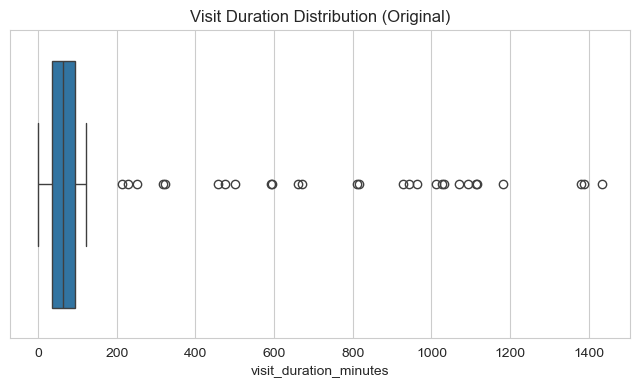

In [120]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["visit_duration_minutes"])
plt.title("Visit Duration Distribution (Original)")
plt.show()

In [288]:
print("Dataset Shape:", df_clean.shape)
print("\nMissing Values:")
print(df_clean.isna().sum())

print("\nUnique Service Types:")
print(df_clean["service_type"].unique())

print("\nUnique Locations:")
print(df_clean["visit_location"].unique())

Dataset Shape: (1000, 42)

Missing Values:
visit_id                     0
patient_id                   0
nurse_id                     0
visit_start_time             0
visit_end_time             100
service_type                 0
visit_location               0
nurse_notes                  0
visit_sequence               0
visit_record_id              0
nurse_notes_clean            0
flag_follow_up               0
flag_review_required         0
flag_urgent                  0
flag_pain                    0
flag_mobility                0
flag_medication              0
flag_wound_care              0
flag_stable                  0
note_match_count             0
flag_monitoring              0
flag_vitals                  0
flag_no_notes                0
matched_keywords             0
flag_exercise                0
flag_patient_condition       0
nurse_notes_hf               0
nurse_notes_nlp              0
note_char_count              0
note_word_count              0
hf_top_label               

***Part 2: Data Analysis and Visualization***

In [190]:
df_clean["visit_duration_minutes"].describe()

count     900.000000
mean       85.794185
std       147.896447
min         0.383333
25%        34.895833
50%        64.000000
75%        94.779167
max      1432.883333
Name: visit_duration_minutes, dtype: float64

Travel duration = time gap between the end of a nurse’s previous visit and the start of the next visit on the same day.

In [191]:
# Sort visits chronologically for each nurse

df_clean = df_clean.sort_values(["nurse_id", "visit_start_time"]).copy()

In [192]:
df_clean["prev_visit_end_time"] = df_clean.groupby("nurse_id")["visit_end_time"].shift(1)
df_clean["prev_visit_location"] = df_clean.groupby("nurse_id")["visit_location"].shift(1)

In [193]:
df_clean["travel_duration_minutes"] = (
    (df_clean["visit_start_time"] - df_clean["prev_visit_end_time"])
    .dt.total_seconds() / 60
)

In [194]:
df_clean.loc[
    df_clean["travel_duration_minutes"] < 0,
    "travel_duration_minutes"
] = np.nan

In [195]:
df_clean["visit_date"] = df_clean["visit_start_time"].dt.date
df_clean["prev_visit_date"] = df_clean.groupby("nurse_id")["visit_date"].shift(1)

df_clean.loc[
    df_clean["visit_date"] != df_clean["prev_visit_date"],
    "travel_duration_minutes"
] = np.nan

In [196]:
df_clean[["visit_duration_minutes", "travel_duration_minutes"]].describe()

,visit_duration_minutes,travel_duration_minutes
count,900.000000,103.000000
mean,85.794185,409.729935
std,147.896447,264.423614
min,0.383333,12.116667
25%,34.895833,181.875000
50%,64.000000,404.533333
75%,94.779167,557.658333
max,1432.883333,1072.733333


***Average visit & travel duration across service types***

In [215]:
# Average visit duration by service type
service_visit_duration = (
    df_clean.groupby("service_type")["visit_duration_minutes"]
    .mean()
    .sort_values(ascending=False)
)

service_visit_duration

service_type
Wound Care                   101.431944
Medication Administration     90.393526
Physical Therapy              75.597235
General Check-up              74.218075
Name: visit_duration_minutes, dtype: float64

In [217]:
# Identify longest and shortest average visit duration
longest_service = service_visit_duration.idxmax()
shortest_service = service_visit_duration.idxmin()

print("Service type with longest average visit duration:", longest_service)
print("Average duration:", round(service_visit_duration.max(), 2), "minutes")

print("\nService type with shortest average visit duration:", shortest_service)
print("Average duration:", round(service_visit_duration.min(), 2), "minutes")

Service type with longest average visit duration: Wound Care
Average duration: 101.43 minutes

Service type with shortest average visit duration: General Check-up
Average duration: 74.22 minutes


***Visit duration by location***

In [218]:
# Average visit duration by location
location_summary = (
    df_clean.groupby("visit_location")["visit_duration_minutes"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

location_summary

,count,mean,median,std
visit_location,,,,
North,232,107.809842,73.075,205.394656
South,217,91.004608,66.000,164.221379
East,218,72.232951,65.000,81.172169
West,233,71.708584,54.000,102.957873


In [265]:
from scipy.stats import shapiro

print("Normality Test (Shapiro-Wilk) by Location")

for location, group in df_clean.groupby("visit_location"):
    
    stat, p = shapiro(group["visit_duration_minutes"].dropna())
    
    print(f"{location}: p-value = {p:.4f}")

Normality Test (Shapiro-Wilk) by Location
East: p-value = 0.0000
North: p-value = 0.0000
South: p-value = 0.0000
West: p-value = 0.0000


All groups fail the normality test (p < 0.05 → reject normality assumption)

In [266]:
from scipy.stats import kruskal

location_groups = [
    group["visit_duration_minutes"].dropna()
    for _, group in df_clean.groupby("visit_location")
]

stat, p = kruskal(*location_groups)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Kruskal-Wallis statistic: 8.787198647054092
p-value: 0.03225816881346135


### Non-Parametric Test: Kruskal–Wallis Comparison Across Locations

Because the Shapiro–Wilk normality test indicated that visit duration is not normally distributed across locations, a **Kruskal–Wallis test** was used as a non-parametric alternative to ANOVA.

The Kruskal–Wallis test compares the distributions of visit duration across multiple groups without assuming normality.

**Results**

- Kruskal–Wallis statistic: **8.79**
- p-value: **0.0323**

Because the p-value is **less than 0.05**, we reject the null hypothesis that all locations have the same distribution of visit durations.

### Interpretation

This result suggests that **visit duration differs significantly across geographic locations**. In other words, at least one location has a different distribution of visit durations compared to the others.

Earlier descriptive analysis showed that:

- **North** had the highest average visit duration
- **South** had moderate visit duration
- **East and West** had shorter visit durations

These differences may reflect variations in:

- patient complexity
- service demand across regions
- operational workflows
- travel or scheduling patterns



In [267]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [268]:
import scikit_posthocs as sp

# Dunn's post-hoc test with Bonferroni correction
dunn_results = sp.posthoc_dunn(
    df_clean,
    val_col="visit_duration_minutes",
    group_col="visit_location",
    p_adjust="bonferroni"
)

dunn_results

,East,North,South,West
East,1.000000,1.000000,1.000000,0.956528
North,1.000000,1.000000,1.000000,0.067601
South,1.000000,1.000000,1.000000,0.295537
West,0.956528,0.067601,0.295537,1.000000


### Post-hoc Pairwise Comparison (Dunn Test)

Following the significant Kruskal–Wallis test, a Dunn post-hoc test with Bonferroni correction was performed to identify which specific location pairs differ in visit duration.

The pairwise p-values indicate that **none of the location comparisons are statistically significant at the 0.05 level after multiple comparison correction**.

The closest comparison was between **North and West locations (p ≈ 0.068)**, suggesting a possible difference, although it does not meet the conventional significance threshold.

### Interpretation

While the Kruskal–Wallis test indicates that visit duration distributions differ overall across locations, the Dunn post-hoc analysis suggests that **no single pair of locations shows a statistically significant difference when adjusting for multiple comparisons**.

This may occur when the overall variation across groups is moderate but not large enough between individual pairs to reach significance after correction.

In practical terms, the results suggest **some regional variation in visit duration**, but the differences between individual locations are relatively subtle.

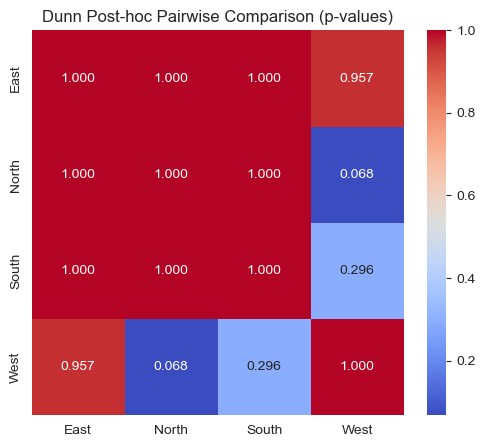

In [271]:
plt.figure(figsize=(6,5))
sns.heatmap(dunn_results, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Dunn Post-hoc Pairwise Comparison (p-values)")
plt.show()

***Top 3 and Bottom 3 nurses by travel time***

In [272]:
# Nurse-level average travel duration
nurse_travel_summary = (
    df_clean.groupby("nurse_id")["travel_duration_minutes"]
    .agg(["count", "mean", "median", "std"])
    .dropna()
)

# Use only nurses with at least 2 valid travel observations so the ranking is less noisy.
nurse_travel_summary = nurse_travel_summary[nurse_travel_summary["count"] >= 2]

# Sort by average travel duration
nurse_travel_summary = nurse_travel_summary.sort_values("mean")

nurse_travel_summary.head(10)

,count,mean,median,std
nurse_id,,,,
N8880,2,78.808333,78.808333,32.750829
N1148,2,107.991667,107.991667,62.260752
N5275,3,160.027778,106.666667,155.850563
N3280,2,230.400000,230.400000,152.357941
N9428,3,289.438889,327.933333,227.959152
N1568,2,290.833333,290.833333,254.794143
N6797,2,290.933333,290.933333,234.500179
N7325,4,302.266667,174.225000,273.094482
N2044,2,321.075000,321.075000,174.054334


In [273]:
# Bottom 3 nurses (shortest average travel duration)
bottom_3_nurses = nurse_travel_summary.head(3)
bottom_3_nurses

,count,mean,median,std
nurse_id,,,,
N8880,2,78.808333,78.808333,32.750829
N1148,2,107.991667,107.991667,62.260752
N5275,3,160.027778,106.666667,155.850563


In [274]:
# Top 3 nurses (longest average travel duration)
top_3_nurses = nurse_travel_summary.tail(3).sort_values("mean", ascending=False)
top_3_nurses

,count,mean,median,std
nurse_id,,,,
N4803,2,789.741667,789.741667,337.419571
N3933,3,685.377778,649.666667,370.792007
N9346,3,654.483333,713.800000,319.037797


In [275]:
# Overall average travel duration
overall_avg_travel = df_clean["travel_duration_minutes"].mean()
print("Overall average travel duration:", round(overall_avg_travel, 2), "minutes")

Overall average travel duration: 409.73 minutes


***Insights from nurse_notes***

In [276]:
# Average visit duration by nurse note category
note_duration_summary = (
    df_clean.groupby("hf_top_label")["visit_duration_minutes"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

note_duration_summary

,count,mean,median,std
hf_top_label,,,,
wound care,81,123.570576,71.000000,243.568514
stable condition,180,105.335185,62.000000,196.335287
review required,66,98.093434,67.033333,144.192084
medication administration,79,84.856751,78.800000,117.614204
pain management,13,83.612821,90.066667,56.050180
no notes provided,93,77.186559,62.350000,140.378766
urgent or critical care,87,71.676437,60.000000,109.523690
mobility or rehabilitation,50,70.337333,73.000000,32.614606
vital signs check,3,69.144444,56.433333,26.859435


In [277]:
# Top note categories associated with longest average visit duration
note_duration_summary.head(10)

,count,mean,median,std
hf_top_label,,,,
wound care,81,123.570576,71.000000,243.568514
stable condition,180,105.335185,62.000000,196.335287
review required,66,98.093434,67.033333,144.192084
medication administration,79,84.856751,78.800000,117.614204
pain management,13,83.612821,90.066667,56.050180
no notes provided,93,77.186559,62.350000,140.378766
urgent or critical care,87,71.676437,60.000000,109.523690
mobility or rehabilitation,50,70.337333,73.000000,32.614606
vital signs check,3,69.144444,56.433333,26.859435


In [278]:
# Compare visit duration when note flags are present vs absent
flag_cols = [col for col in df_clean.columns if col.startswith("flag_")]

flag_impact_results = []

for col in flag_cols:
    if df_clean[col].dropna().nunique() >= 2:
        grouped = df_clean.groupby(col)["visit_duration_minutes"].mean()
        flag_impact_results.append({
            "flag": col,
            "avg_duration_when_true": grouped.get(True, np.nan),
            "avg_duration_when_false": grouped.get(False, np.nan),
            "difference_true_minus_false": grouped.get(True, np.nan) - grouped.get(False, np.nan)
        })

flag_impact_summary = (
    pd.DataFrame(flag_impact_results)
    .sort_values("difference_true_minus_false", ascending=False)
)

flag_impact_summary

,flag,avg_duration_when_true,avg_duration_when_false,difference_true_minus_false
6,flag_wound_care,105.363267,80.167024,25.196243
7,flag_stable,100.253768,83.675902,16.577866
1,flag_review_required,94.968095,85.020482,9.947613
5,flag_medication,87.216359,85.342338,1.874022
4,flag_mobility,84.887559,85.964028,-1.076469
11,flag_exercise,79.653490,87.448449,-7.794958
9,flag_vitals,79.088272,87.266215,-8.177943
10,flag_no_notes,77.186559,86.786142,-9.599583
0,flag_follow_up,72.086240,87.242445,-15.156204
2,flag_urgent,73.512085,89.555467,-16.043382


***Visualization***


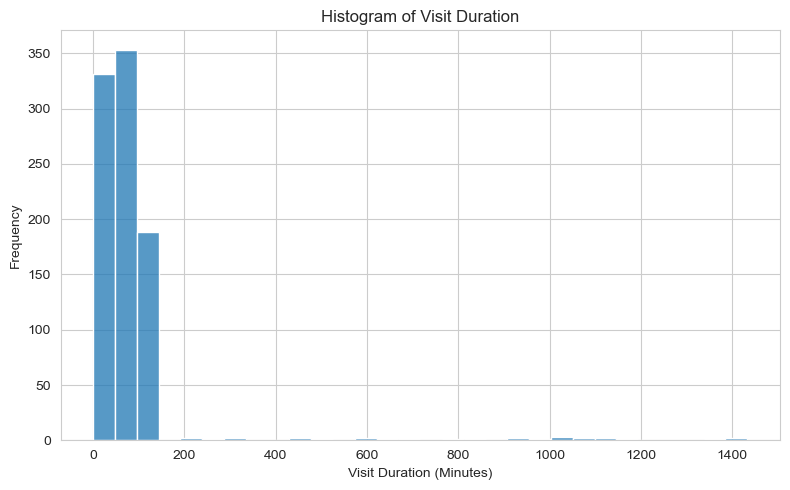

In [279]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["visit_duration_minutes"].dropna(), bins=30)
plt.title("Histogram of Visit Duration")
plt.xlabel("Visit Duration (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

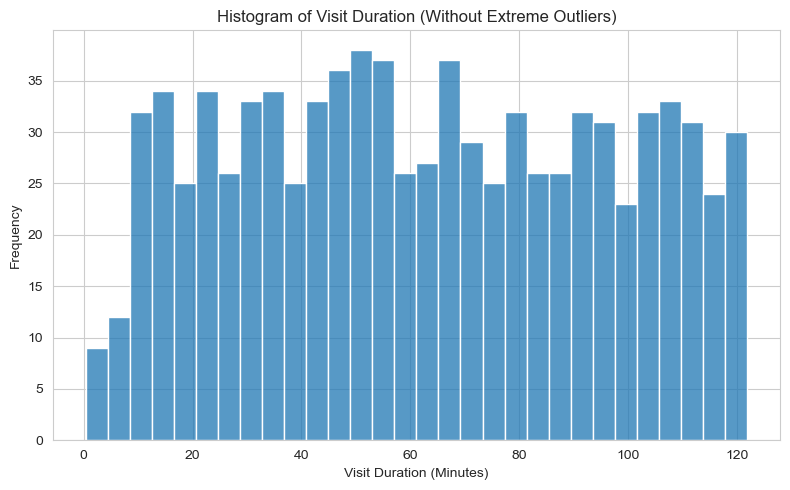

In [280]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_clean.loc[~df_clean["duration_outlier"], "visit_duration_minutes"].dropna(),
    bins=30
)
plt.title("Histogram of Visit Duration (Without Extreme Outliers)")
plt.xlabel("Visit Duration (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

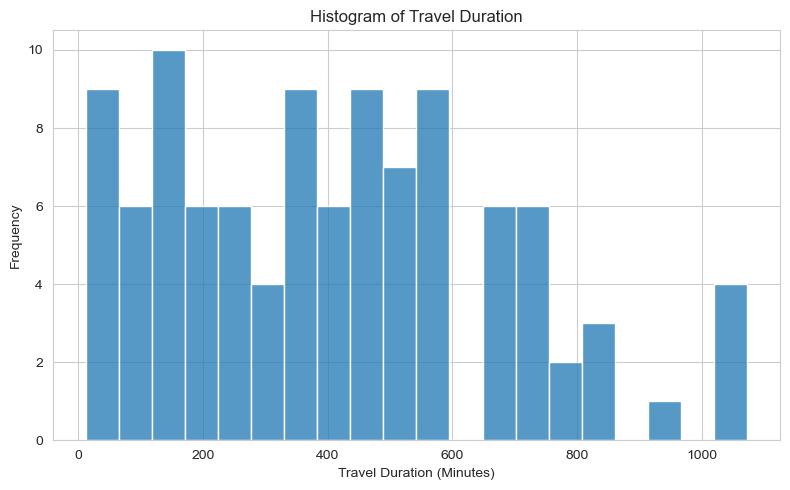

In [281]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["travel_duration_minutes"].dropna(), bins=20)
plt.title("Histogram of Travel Duration")
plt.xlabel("Travel Duration (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

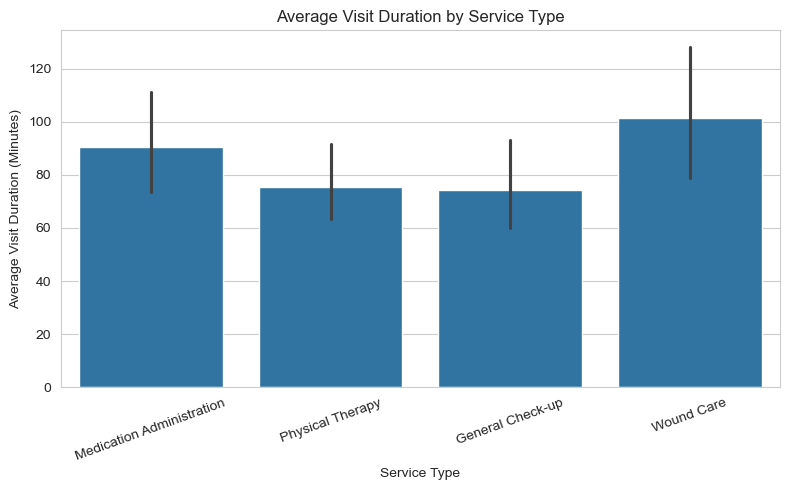

In [282]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_clean,
    x="service_type",
    y="visit_duration_minutes",
    estimator=np.mean
)
plt.title("Average Visit Duration by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Visit Duration (Minutes)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

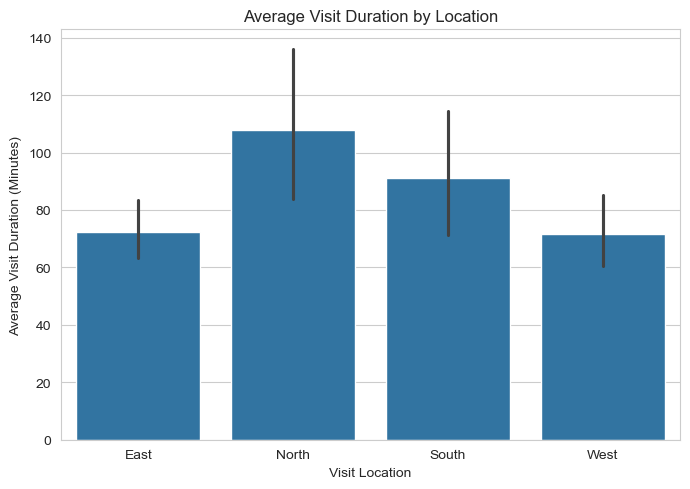

In [283]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_clean,
    x="visit_location",
    y="visit_duration_minutes",
    estimator=np.mean
)
plt.title("Average Visit Duration by Location")
plt.xlabel("Visit Location")
plt.ylabel("Average Visit Duration (Minutes)")
plt.tight_layout()
plt.show()

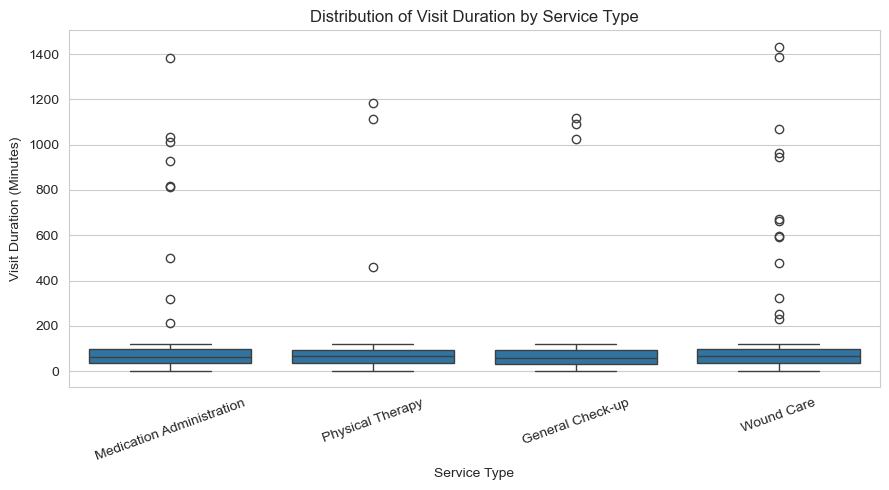

In [284]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="service_type",
    y="visit_duration_minutes"
)
plt.title("Distribution of Visit Duration by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Visit Duration (Minutes)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

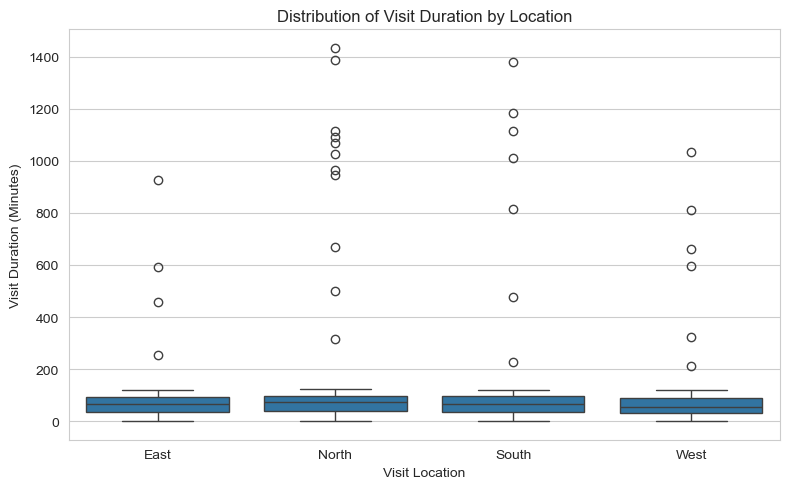

In [285]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="visit_location",
    y="visit_duration_minutes"
)
plt.title("Distribution of Visit Duration by Location")
plt.xlabel("Visit Location")
plt.ylabel("Visit Duration (Minutes)")
plt.tight_layout()
plt.show()

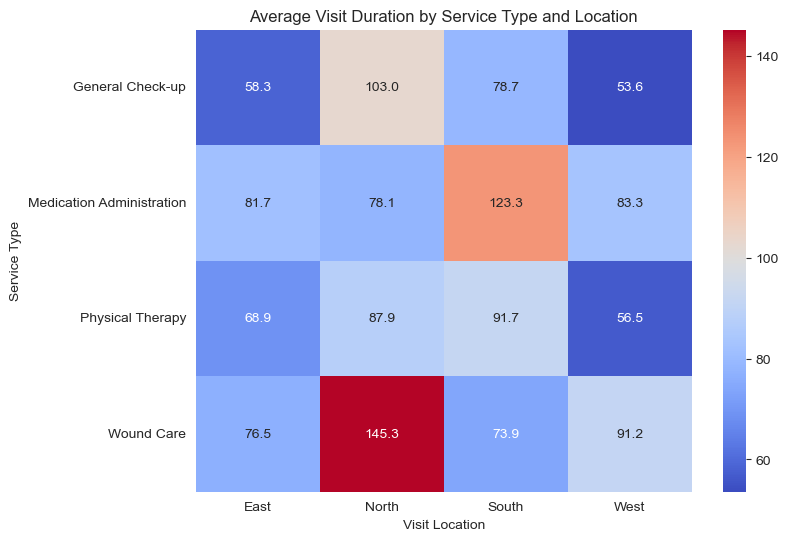

In [290]:
plt.figure(figsize=(8,6))

pivot = df_clean.pivot_table(
    values="visit_duration_minutes",
    index="service_type",
    columns="visit_location",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Average Visit Duration by Service Type and Location")
plt.xlabel("Visit Location")
plt.ylabel("Service Type")

plt.show()

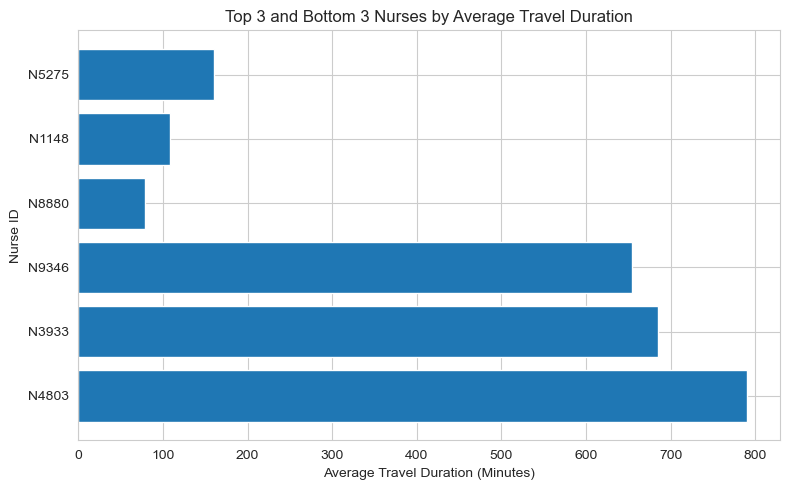

In [286]:
nurse_compare_plot = pd.concat([top_3_nurses, bottom_3_nurses]).copy()
nurse_compare_plot["group"] = ["Top 1", "Top 2", "Top 3", "Bottom 1", "Bottom 2", "Bottom 3"]

plt.figure(figsize=(8, 5))
plt.barh(
    nurse_compare_plot.index.astype(str),
    nurse_compare_plot["mean"]
)
plt.title("Top 3 and Bottom 3 Nurses by Average Travel Duration")
plt.xlabel("Average Travel Duration (Minutes)")
plt.ylabel("Nurse ID")
plt.tight_layout()
plt.show()

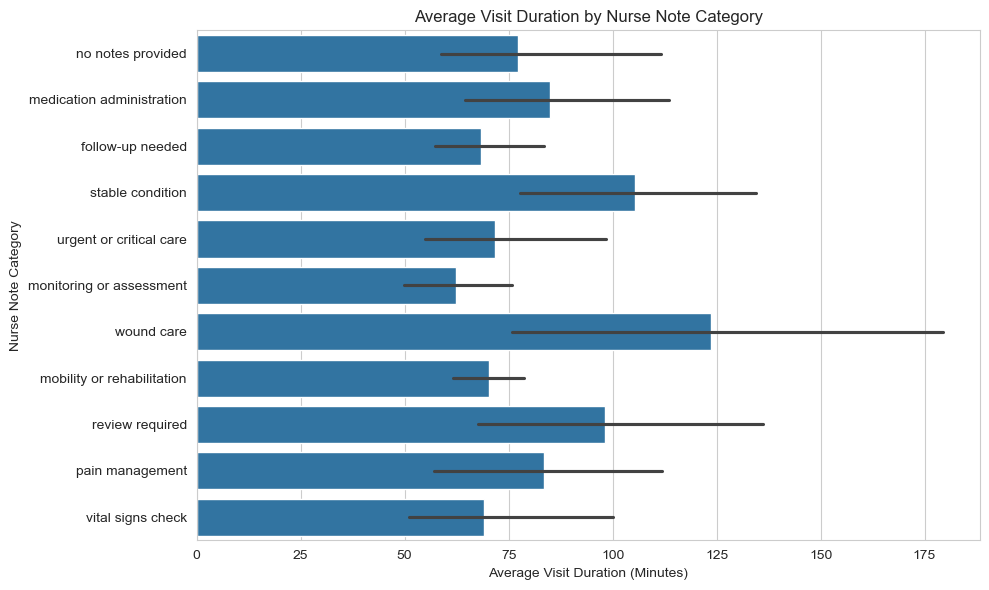

In [287]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_clean,
    y="hf_top_label",
    x="visit_duration_minutes",
    estimator=np.mean
)
plt.title("Average Visit Duration by Nurse Note Category")
plt.xlabel("Average Visit Duration (Minutes)")
plt.ylabel("Nurse Note Category")
plt.tight_layout()
plt.show()

### Interpretation: Visit Duration by Service Type

The analysis shows meaningful differences in average visit duration across service types.

- **Wound Care** has the longest average visit duration (~101 minutes). This is expected because wound care often requires cleaning, dressing changes, and careful monitoring, which are time-intensive procedures.
- **Medication Administration** visits average around 90 minutes, reflecting the time required for medication preparation, patient monitoring, and documentation.
- **Physical Therapy** and **General Check-ups** have shorter average durations (approximately 75 and 74 minutes respectively), likely because these visits follow more standardized procedures.

Overall, the results suggest that visit duration is strongly influenced by the **complexity of the service being delivered**, with more clinical or procedural services requiring longer time at the patient’s location.

### Interpretation: Visit Duration by Location

Average visit duration varies across geographic service areas.

- The **North region** has the highest average visit duration (approximately **108 minutes**).
- The **South region** follows with an average around **91 minutes**.
- **East and West regions** show shorter average visit durations (around **72 minutes**).

These descriptive differences suggest that visits in the North region tend to take longer than in other areas.

However, statistical testing provides additional context. The **Kruskal–Wallis test indicated a significant overall difference in visit duration across locations**, suggesting that location may influence visit duration. 

A **Dunn post-hoc test with Bonferroni correction** was then performed to identify which specific locations differ. The results showed that **no individual pair of locations had a statistically significant difference at the 0.05 level after correction**, although the comparison between **North and West locations approached significance (p ≈ 0.068)**.

Overall, the findings suggest **moderate regional variation in visit duration**, potentially influenced by differences in patient needs, service complexity, or operational workflows across regions.

### Interpretation: Nurse Travel Duration

Travel duration between visits varies significantly across nurses.

The analysis identified the **top 3 nurses with the longest average travel times** and the **bottom 3 nurses with the shortest travel times**.

- Some nurses (e.g., N4803, N3933, and N9346) have extremely high average travel durations, suggesting they may cover larger geographic areas or serve patients in more remote locations.
- In contrast, nurses such as N8880 and N1148 have much shorter travel durations, which may indicate more geographically concentrated patient assignments.

The **overall average travel duration is approximately 409 minutes**, which appears high and may include long gaps between visits, such as overnight intervals or scheduling breaks.

These findings highlight potential opportunities for **route optimization and workload balancing** to reduce travel inefficiencies.

### Interpretation: Visit Duration by Nurse Note Category

Visit duration was also analyzed based on the primary category extracted from nurse notes.

Some note categories are associated with longer visit durations:

- **Wound care** has the longest average visit duration (~123 minutes), reinforcing earlier findings from the service-type analysis.
- **Stable condition** and **review required** visits also show relatively long durations, suggesting that these visits may involve additional monitoring or documentation.

Shorter visit durations are associated with categories such as:

- **Monitoring or assessment**
- **Follow-up needed**
- **Vital signs check**

These categories likely represent routine evaluations that require less time compared to complex clinical procedures.

Overall, the results demonstrate that **clinical context captured in nurse notes can provide useful insight into visit duration variability**.

### Heatmap Interpretation: Service Type and Location

The heatmap highlights how visit duration varies across both service type and geographic location.

Several patterns are visible:

- **Wound Care in the North region** has the longest average visit duration (approximately 150 minutes), suggesting higher case complexity or more intensive treatment requirements.
- **Medication Administration in the South region** also shows relatively long visit durations compared to other locations.
- **General Check-ups and Physical Therapy visits** tend to be shorter overall, particularly in the East and West regions.

These patterns suggest that both **service complexity and regional factors** influence visit duration. Operational planning may benefit from accounting for these differences when scheduling nurse workloads across regions.

### Interpretation: Impact of Clinical Flags on Visit Duration

To further understand factors influencing visit duration, several binary clinical flags were analyzed.

The largest positive differences in visit duration occur when the following flags are present:

- **Wound care flag (+25 minutes)**
- **Stable condition flag (+16 minutes)**
- **Review required flag (+9 minutes)**

These flags likely represent visits requiring additional procedures, monitoring, or documentation.

Conversely, some flags are associated with shorter visits when present, such as:

- **Pain management**
- **Monitoring**
- **Follow-up**
- **Patient condition updates**

These may represent more focused or routine visits that require less time on site.

Overall, the analysis suggests that **clinical flags extracted from nurse notes provide meaningful signals about visit complexity and time requirements**.

## Operational Efficiency Recommendations

Based on the analysis of visit duration, travel time, service types, and nurse note categories, several opportunities emerge to improve operational efficiency.

### 1. Optimize Nurse Routing and Geographic Assignment
The analysis revealed large differences in average travel durations between nurses. Some nurses experience significantly longer travel times, likely due to wider geographic coverage or inefficient routing.

Possible improvements include:
- Assigning nurses to **more geographically concentrated patient clusters**
- Implementing **route optimization tools** to minimize travel distance between visits
- Balancing workloads to ensure nurses have similar travel demands

Reducing travel time can increase the number of visits a nurse can complete per day while reducing fatigue.

### 2. Adjust Scheduling Based on Service Complexity
Visit duration varies substantially by service type. For example:
- **Wound care visits take the longest**
- **General check-ups and physical therapy visits are shorter on average**

Scheduling systems could account for this by:
- Allocating **longer appointment slots for complex procedures**
- Grouping **shorter visits together within the same scheduling block**
- Avoiding overbooking when multiple complex visits are scheduled consecutively

This can improve scheduling accuracy and reduce delays throughout the day.

### 3. Use Nurse Notes to Predict Visit Complexity
The nurse notes analysis shows that certain clinical categories (such as wound care or review-required visits) are associated with longer visit durations.

Operational systems could:
- Use **note categories or flags to predict expected visit duration**
- Automatically adjust scheduling time blocks based on predicted complexity
- Provide alerts when multiple complex visits are scheduled back-to-back

This would allow more realistic planning of nurse workloads.

### 4. Investigate Regional Differences in Visit Duration
The statistical analysis showed a **significant difference in visit duration across locations**, with the North region having the longest average visits.

This suggests the need to examine:
- Differences in patient case complexity by region
- Regional staffing levels
- Travel logistics and patient density

Addressing these regional differences could improve resource allocation and service consistency.

### 5. Monitor and Manage Extreme Visit Durations
The distribution of visit duration shows some extreme outliers. While some long visits may reflect legitimate complex care, others may indicate documentation delays or scheduling inefficiencies.

Possible actions include:
- Monitoring unusually long visits for operational review
- Providing additional support or training for complex cases
- Adjusting scheduling buffers to accommodate unexpected delays

### Overall Recommendation
Combining **data-driven scheduling, geographic route optimization, and predictive insights from nurse notes** could significantly improve operational efficiency. These improvements may help reduce travel time, balance nurse workloads, and ensure that patient care visits are scheduled more accurately.